# 运行一个简单的 Tick 数据服务器


本节演示如何基于模拟的金融工具价格，运行一个简单的 tick 数据服务器。价格生成模型采用无股息的几何布朗运动（GBM）；该模型有精确的欧拉离散形式，见式 7-1。其中 $S$ 为工具价格，$r$ 为常数短期利率，$\sigma$ 为常数波动率因子，$z$ 为标准正态随机变量，$\Delta t$ 为两次离散观测之间的时间间隔。

式 7-1. 几何布朗运动的欧拉离散

$$S_t = S_{t-\Delta t} \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, z\right)$$

https://www.youtube.com/watch?v=R8pDHvPWtE4

基于该模型，同目录 `TickServer.py` 给出用 ZeroMQ 实现的完整 tick 服务器；下文拆解其中的 `InstrumentPrice` 与主循环。发布过程有两处随机性：一是股价由蒙特卡洛模拟给出；二是两次发布之间的时间间隔也随机。下文按脚本主要部分说明。


## 1. 导入与 PUB 套接字

脚本开头完成若干导入（含 ZeroMQ 的 Python 封装），并创建打开 `PUB` 类型套接字所需的主要对象：


In [1]:
import zmq                                     # (1) imports the Python wrapper for the ZeroMQ library https://zeromq.org/
import math
import time
import random
from datetime import datetime

context = zmq.Context()                        # (2) a Context object is instantiated; it is the central object for socket communication
socket = context.socket(zmq.PUB)               # (3) the socket is defined based on the PUB socket type ("communication pattern")
socket.bind('tcp://0.0.0.0:5555')              # (4) bind to the local IP address (0.0.0.0 on Linux and Mac OS,
                                               #     127.0.0.1 on Windows) and port number 5555


<SocketContext(bind='tcp://0.0.0.0:5555')>

## 2. `InstrumentPrice` 类

`InstrumentPrice` 用于随时间模拟工具价格。属性包括几何布朗运动的主要参数，以及标的代码与实例创建时刻。唯一方法 `.simulate_value()` 根据距上次调用经过的时间与一个随机因子，生成新的股价：


In [2]:
class InstrumentPrice(object):
    def __init__(self):
        self.symbol = 'SYMBOL'
        self.t = time.time()                            # (1) stores the time of the initialization
        self.value = 100.0
        self.sigma = 0.4
        self.r = 0.01

    def simulate_value(self):
        ''' Generates a new, random stock price.
        '''
        t = time.time()                                 # (2) current time is recorded when the method is called
        seconds_per_trading_year = 252 * 8 * 60 * 60
        dt_scale = 500                                  # arbitrary factor to amplify price moves for the demo
        dt = (t - self.t) / seconds_per_trading_year    # (3) dt: time interval between now and self.t, in (trading) year fractions
        dt *= dt_scale                                  # (4) scale dt (by an arbitrary factor) to get larger price movements
        self.t = t                                      # (5) update self.t: reference point for the next call
        self.value *= math.exp((self.r - 0.5 * self.sigma ** 2) * dt + self.sigma * math.sqrt(dt) * random.gauss(0, 1))  # (6) new price via Euler scheme for GBM
        return self.value


## 3. 主循环

脚本主体是实例化一个 `InstrumentPrice` 对象，以及一个无限 `while` 循环。循环中模拟新价格，构造消息并打印，再经套接字发送；最后随机暂停一段时间。

注意：这是无限循环，在 notebook 里直接运行会一直阻塞。请直接在终端执行同目录的 `python TickServer.py`。


In [3]:
ip = InstrumentPrice()                                                  # (1) instantiate an InstrumentPrice object

while True:                                                             # (2) start an infinite while loop
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]           # ms precision
    msg = '{} {} {:.2f}'.format(ts, ip.symbol, ip.simulate_value())     # (3) message text from symbol attribute + newly simulated price
    print(msg)                                                          # (4) print the message str object to standard out
    socket.send_string(msg)                                             # (5) also send it to subscribed sockets
    time.sleep(random.random() * 2)                                     # (6) pause for a random time (0 to 2 seconds),
                                                                        #     simulating random arrival of new tick data


2026-10-01 12:06:32.931 SYMBOL 100.00
2026-10-01 12:06:32.947 SYMBOL 99.98
2026-10-01 12:06:34.436 SYMBOL 100.26
2026-10-01 12:06:36.094 SYMBOL 99.84
2026-10-01 12:06:37.354 SYMBOL 100.08
2026-10-01 12:06:38.600 SYMBOL 100.28
2026-10-01 12:06:38.642 SYMBOL 100.18
2026-10-01 12:06:38.644 SYMBOL 100.20


KeyboardInterrupt: 

此时还无法验证脚本是否也通过绑定在 `tcp://0.0.0.0:5555`（Windows 上为 `tcp://127.0.0.1:5555`）的套接字发送了同一条消息。为此需要另一个订阅该发布端的套接字，才能凑成一对。

补充：金融工具价格的蒙特卡洛模拟常依赖均匀时间间隔（例如“一个交易日”）。在较长区间的日终收盘价场景下，这种近似往往够用。但在日内 tick 数据里，随机到达是重要特征，需要纳入模型。本 tick 服务器脚本通过随机暂停时长来实现随机到达时间。


## 4. 补充：看一眼几何布朗运动长什么样

本节服务器逻辑与套接字发布到此结束。若只想直观感受式 7-1 的样本路径，可运行下面的单元格：用同一套 `InstrumentPrice` 参数连续模拟，价格写入列表，满 1000 个点后不再追加，然后画折线图。不涉及 PUB 套接字，可单独执行；跳过亦不影响上文。


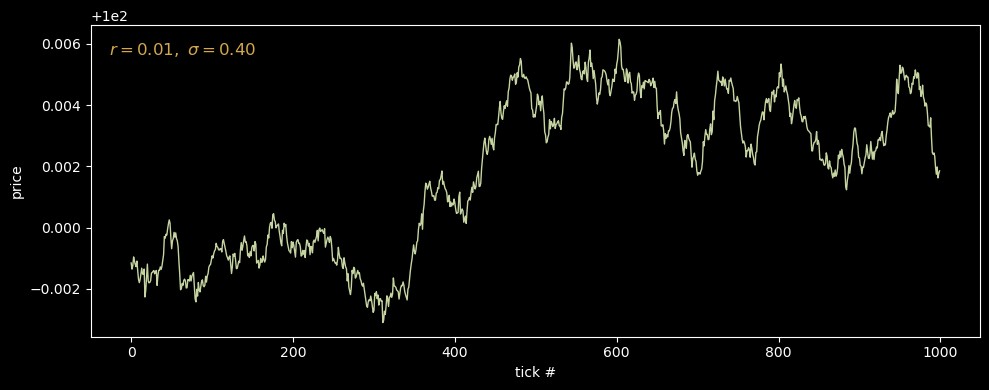

: 

In [ ]:
import matplotlib.pyplot as plt

ip = InstrumentPrice()
prices = []
while len(prices) < 1000:
    prices.append(ip.simulate_value())

fig, ax = plt.subplots(figsize=(10, 4), facecolor='black')
ax.set_facecolor('black')
ax.plot(prices, color='#c5d4a0', lw=1.0)
ax.text(0.02, 0.95, fr'$r = {ip.r:.2f},\ \sigma = {ip.sigma:.2f}$',
        transform=ax.transAxes, color='#d4a84b', fontsize=12, va='top')
ax.set_xlabel('tick #', color='white')
ax.set_ylabel('price', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
fig.tight_layout()
plt.show()
